In [2]:
# Goal: Simulate an accurate orbit and perihelion precession for TU3 
# (Then it can be applied to the other asteroids)

# Chapter 1: Create a model with all the necessary bodies

# Chapter 2: Apply General Relativity & Solar quadrupole Moment 
# Also apply the Yarkowsky effect
# For this argue why these effects are the only relevant

# -----------------------------------------------------------------------------

# Firstly, follow the example for Solar System Propagation using Multi-Body Dynamics

# Load standard modules
import numpy as np
from matplotlib import pyplot as plt

# Load tudatpy modules
from tudatpy.interface import spice
from tudatpy import dynamics
from tudatpy.dynamics import environment_setup, propagation_setup, propagation, simulator
from tudatpy import constants
from tudatpy.util import result2array
from tudatpy.astro.time_representation import DateTime
from tudatpy.astro import element_conversion
# For the minor planets
from tudatpy.data import horizons

# Additional import
import os           # for the extraction of asteroid kernels


In [3]:
# Step 1: Setup Conditions/ Basic Conditions

# Load spice kernels
spice.load_standard_kernels()

# Set simulation start and end epochs (total simulation time of 5 years)
# Start dat = 25th of April 2004 (arbitrary choice)
# Tudat works in J2000, so use seconds
simulation_start_epoch = DateTime(2000, 1, 1).to_epoch() - 12 * 3600
simulation_end_epoch   = simulation_start_epoch + 20 * constants.JULIAN_YEAR


# Step 2: Define bodies in simulation

# The lagrer bodies exist inside of SPICE and are well-defined
larger_bodies_to_create = [
    "Sun",
    # "Earth",
    # "Mercury",
    # "Venus",
    # "Mars",
    # "Jupiter",
    # "Saturn",
    # "Uranus",
    # "Neptune"
]


In [4]:
# In complete case, I would extract the asteroids here

In [5]:
# Manually add 1998 TU3
asteroid_name = "66146"


# Combine all bodies into one large list
bodies_to_create = larger_bodies_to_create + [asteroid_name]
bodies_to_propagate = asteroid_name     # I only propagate TU3, I pull the other values from pre-existing ephemeris


# ----------------------------
# Create bodies in simulation.

# Pull on the data already known for the larger bodies
body_settings = environment_setup.get_default_body_settings(
    bodies = larger_bodies_to_create, 
    base_frame_origin = 'Sun',              # Correct as initial conditions from JPL are in SSB
    base_frame_orientation = 'J2000')       # Intiial conditions from JPL are in J2000


# Manually add empty settings for TU3
body_settings.add_empty_settings(asteroid_name)

# Know that I then create the environment below before the acceleration

In [6]:
# Step 3: Create the Propagation Setup

bodies_to_propagate = ["66146"]

central_bodies = ["Sun"]

In [7]:
# Define the solar quadrupole moment
# See Book by Montenbruck and Gill, pg 57-58 for the conversion/ equations
# To understand function see: https://py.api.tudat.space/en/latest/dynamics/environment_setup/gravity_field.html#tudatpy.dynamics.environment_setup.gravity_field.spherical_harmonic

# For the Sun's gravitational potential, Sn0 is zero by definition

J_2 = 2.2 * 10**(-7) + 1 * 10**(-8)
norm_C_20 = - J_2 / np.sqrt(5)

norm_cosine_coeffs = np.array([
    [1.0, 0.0, 0.0],
    [0.0, 0.0, 0.0],
    [norm_C_20, 0.0, 0.0]
])

norm_sine_coeffs = np.array([
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0]
])

# Technically I've defined this below as well
mu_Sun = 1.327124400420322e+20
radius_Sun = 695.99 * 10**6 + 0.07 * 10**6 # m

body_settings.get("Sun").gravity_field_settings = (
    environment_setup.gravity_field.spherical_harmonic(
        gravitational_parameter = mu_Sun,
        reference_radius = radius_Sun,
        normalized_cosine_coefficients = norm_cosine_coeffs,
        normalized_sine_coefficients = norm_sine_coeffs,
        # Ensure Tudat knows that the values are defined in the Sun's fixed frame
        # The International Astronomical Union (IAU) defines standard body-fixed frames for well-known bodies
        associated_reference_frame = "IAU_Sun"      # Ensures that the buldge rotates with the body
    )
)

In [8]:
# For TU3 the value of A2 is computed 

avg_a_TU3_greenberg = -5.60 * 10**(-4)                       # AU / Myr 
avg_a_TU3_calc = -5.60 * 10**(-4) / (10**6 * 365)            # AU / days
uncertain_avg_a_TU3_greenberg = 3.9 * 10**(-4)               # AU / Mry
uncertain_avg_a_TU3_calc = 3.9 * 10**(-4) / (10**6 * 365)    # AU / days

a_TU3_calc = 0.7875484323220899 # AU
e_TU3_calc = 0.4836694929440215 # unitless
n_TU3_calc = 1.410224212386279  # degrees/ days (remember that angles are unitless in unit conversion)

A_2_TU3_AUdays2 = avg_a_TU3_calc * (np.deg2rad(n_TU3_calc) * (a_TU3_calc**2) * (1 - (e_TU3_calc**2))) / 2
A_2_TU3_uncertainty_AUdays2 = uncertain_avg_a_TU3_calc * (np.deg2rad(n_TU3_calc) * (a_TU3_calc**2) * (1 - (e_TU3_calc**2))) / 2

# A_2_TU3_AUdays2 = avg_a_TU3_calc * ((n_TU3_calc) * (a_TU3_calc**2) * (1 - (e_TU3_calc**2))) / 2
# A_2_TU3_uncertainty_AUdays2 = uncertain_avg_a_TU3_calc * ((n_TU3_calc) * (a_TU3_calc**2) * (1 - (e_TU3_calc**2))) / 2

print(f"The Yarkovksy parameter for TU3: {A_2_TU3_AUdays2} AU / days^2")
print(A_2_TU3_uncertainty_AUdays2)

# Units from AU/days2 to m/s2
A_2_TU3_ms2 = A_2_TU3_AUdays2 * 149597870691 / ((24 * 3600)**2)
A_2_TU3_uncertainty_ms2 = A_2_TU3_uncertainty_AUdays2 * 149597870691 / ((24 * 3600)**2)

print(A_2_TU3_ms2)
print(A_2_TU3_uncertainty_ms2)

A_2_TU3_ms2_uncertainty = A_2_TU3_ms2 + A_2_TU3_uncertainty_ms2

The Yarkovksy parameter for TU3: -8.971192934635577e-15 AU / days^2
6.247795079478349e-15
-1.7978279328752275e-13
1.2520587389666763e-13


In [9]:
# Thus, the environment becomes:
body_system = environment_setup.create_system_of_bodies(body_settings)

In [10]:
# The planets
accelerations_planets = {
    "Sun": [
        # The Sun's gravity 
        propagation_setup.acceleration.point_mass_gravity(), 
        # A spherical harmonic (not just a point mass, but also the solar quadrupole moment)
        # propagation_setup.acceleration.spherical_harmonic_gravity(2, 0),
        # Activating General Relativity (exerted by the Sun / the largest body)
        # Sufficient to use the Schwarzschild Correction
        propagation_setup.acceleration.relativistic_correction(use_schwarzschild=True), # General Relativity
        # Yarkovsky correction
        # propagation_setup.acceleration.yarkovsky(A_2_TU3_ms2_uncertainty),
        # propagation_setup.acceleration.radiation_pressure(), 
    ],
    # "Mercury": [propagation_setup.acceleration.point_mass_gravity()],
    # "Venus": [propagation_setup.acceleration.point_mass_gravity()],
    # "Earth": [propagation_setup.acceleration.point_mass_gravity()],
    # "Mars": [propagation_setup.acceleration.point_mass_gravity()],
    # "Jupiter": [propagation_setup.acceleration.point_mass_gravity()],
    # "Saturn": [propagation_setup.acceleration.point_mass_gravity()],
    # "Uranus": [propagation_setup.acceleration.point_mass_gravity()],
    # "Neptune": [propagation_setup.acceleration.point_mass_gravity()],
}

acceleration_settings_linear = {"66146": accelerations_planets}

In [11]:
# Step 5: Define the Initial States of TU3

sun_gravitational_parameter = body_system.get("Sun").gravitational_parameter

# Grabbing the initial state at 2000-01-01 from JPL with cartesian_to_keplarian() (in astro)

# Cartesian state vector
cartesian_elements = np.array([
    4.543863572576185E+07 * 1e3,   # X  [m]
    -9.673019712424231E+07 * 1e3,  # Y  [m]
    -2.313075952057116E+06 * 1e3,  # Z  [m]
    3.661410298575712E+01 * 1e3,   # VX [m/s]
    -1.757686929389374E+00 * 1e3,  # VY [m/s]
    -3.350242409196601E+00 * 1e3   # VZ [m/s]
], dtype=np.float64)


test_initial_TU3_array = element_conversion.cartesian_to_keplerian(
    cartesian_elements = cartesian_elements,
    gravitational_parameter = sun_gravitational_parameter
    )

print("Keplerian Elements:")
print(test_initial_TU3_array)
print(test_initial_TU3_array[0])
print(test_initial_TU3_array[2])

    # ---------------------------------
    # New initial condition

initial_state_TU3 = element_conversion.keplerian_to_cartesian_elementwise(
    gravitational_parameter = sun_gravitational_parameter,
    semi_major_axis = test_initial_TU3_array[0],                 #meters
    eccentricity = test_initial_TU3_array[1],                    #unitless
    inclination = test_initial_TU3_array[2],                     # cartesian_to_keplerian returns angles in radians
    argument_of_periapsis = test_initial_TU3_array[3],
    longitude_of_ascending_node = test_initial_TU3_array[4],
    true_anomaly = test_initial_TU3_array[5],                
)

# sigma_a = 25.55              # m
# sigma_e = 2.8966e-9          # dimensionless
# sigma_i = 8.3577e-10         # rad
# sigma_peri = 1.7675e-8       # rad
# sigma_node = 1.5686e-8       # rad
# sigma_true_anomaly = 1.08e-7 # rad (estimated from sigma_M)

# initial_state_TU3_error = element_conversion.keplerian_to_cartesian_elementwise(
#     gravitational_parameter = sun_gravitational_parameter,
#     semi_major_axis = test_initial_TU3_array[0] + sigma_a,                 #meters
#     eccentricity = test_initial_TU3_array[1] + sigma_e,                    #unitless
#     inclination = test_initial_TU3_array[2] + sigma_i,                     # cartesian_to_keplerian returns angles in radians
#     argument_of_periapsis = test_initial_TU3_array[3] + sigma_peri,
#     longitude_of_ascending_node = test_initial_TU3_array[4] + sigma_node,
#     true_anomaly = test_initial_TU3_array[5] + sigma_true_anomaly,                
# )
 
# With errors

# initial_state_TU3 = element_conversion.keplerian_to_cartesian_elementwise(
#     gravitational_parameter = sun_gravitational_parameter,
#     semi_major_axis = test_initial_TU3_array[0] + 1.7082E-10,                 #meters
#     eccentricity = test_initial_TU3_array[1] + 2.8966E-9,                    #unitless
#     inclination = test_initial_TU3_array[2] + np.deg2rad(4.7886E-8),                     # cartesian_to_keplerian returns angles in radians
#     argument_of_periapsis = test_initial_TU3_array[3] + np.deg2rad(1.0127E-6),
#     longitude_of_ascending_node = test_initial_TU3_array[4] + np.deg2rad(8.9876E-7),
#     true_anomaly = test_initial_TU3_array[5],                
# )  
    # ---------------------------------

system_initial_state = initial_state_TU3


# Step 6: Create the conditions for propagation:

# Create termination settings
termination_settings = propagation_setup.propagator.time_termination(simulation_end_epoch) # 15 years after the epoch begins

# Create numerical integrator settings
fixed_step_size = 3600.0    # each hour
integrator_settings = propagation_setup.integrator.runge_kutta_fixed_step(
    fixed_step_size, 
    coefficient_set=propagation_setup.integrator.CoefficientSets.rkf_78     # Range-Kutta 78 instead of 4 (more precise as I do 1 hour steps for many years)
)



Keplerian Elements:
[1.17640978e+11 4.74911638e-01 9.41948277e-02 1.48670034e+00
 1.77880117e+00 1.88703315e+00]
117640977822.613
0.09419482774380611


In [12]:
# Create the acceleration model
acceleration_models = (
    propagation_setup.create_acceleration_models(
        body_system,
        acceleration_settings_linear,
        bodies_to_propagate,
        central_bodies
    )
)



# Propagating TU3 with the created system
propagator_settings = propagation_setup.propagator.translational(
    central_bodies,
    acceleration_models,
    bodies_to_propagate,
    system_initial_state,
    simulation_start_epoch,
    integrator_settings,
    termination_settings
)



# Create simulation object and propagate the dynamics
dynamics_simulator = simulator.create_dynamics_simulator(
    body_system, propagator_settings
)

# Extract the resulting state history and convert it to an ndarray
states_TU3 = dynamics_simulator.propagation_results.state_history
states_array_TU3 = result2array(states_TU3)


Single Sun-Orbiting Satellite Example.
The initial position vector of TU3 is [km]: 
[ 45438635.72576186 -96730197.12424232  -2313075.95205713]
The initial velocity vector of TU3 is [km/s]: 
[36.61410299 -1.75768693 -3.35024241]

After 631108800.0 seconds the position vector of TU3 is [km]: 
[ 4.31218798e+07  1.09672422e+08 -6.12578029e+06]
And the velocity vector of TU3 is [km/s]: 
[-33.10553133  -3.91776236   3.13664358]
    


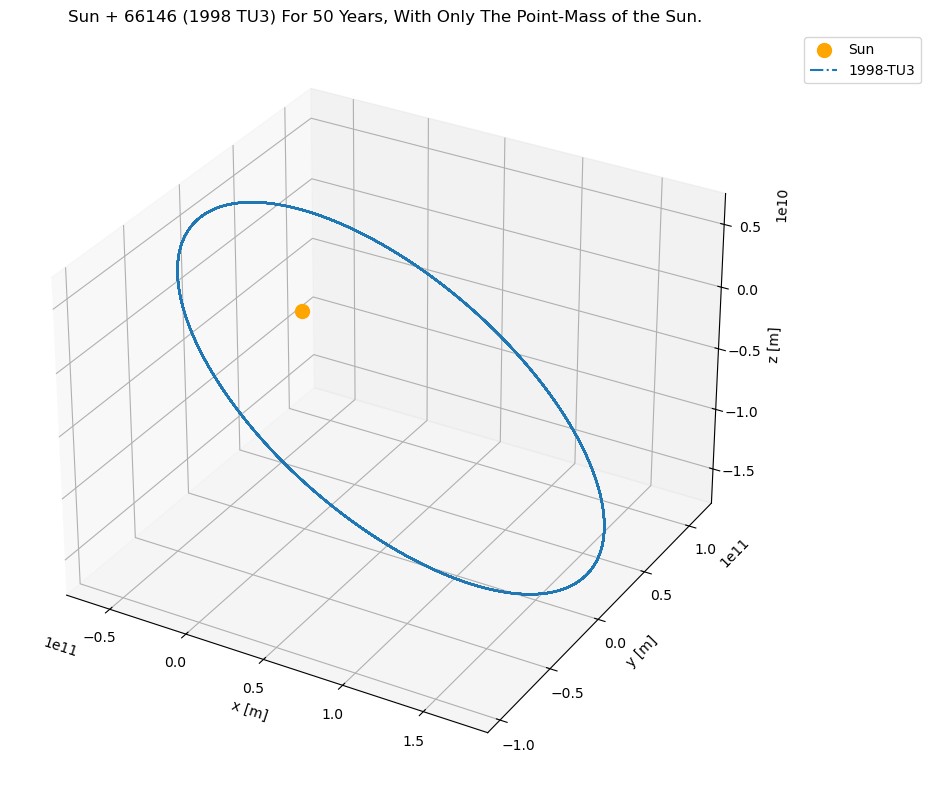

In [13]:
# Extract the times 
times = states_array_TU3[:,0]

print(
    f"""
Single Sun-Orbiting Satellite Example.
The initial position vector of TU3 is [km]: \n{
    states_TU3[simulation_start_epoch][:3] / 1E3}
The initial velocity vector of TU3 is [km/s]: \n{
    states_TU3[simulation_start_epoch][3:] / 1E3}
\nAfter {simulation_end_epoch} seconds the position vector of TU3 is [km]: \n{
    states_TU3[simulation_end_epoch][:3] / 1E3}
And the velocity vector of TU3 is [km/s]: \n{
    states_TU3[simulation_end_epoch][3:] / 1E3}
    """
)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_title('Sun + 66146 (1998 TU3) For 50 Years, With Only The Point-Mass of the Sun.')

ax.scatter(0,0,0,s=100,label="Sun", color='orange')

ax.plot(
    states_array_TU3[:,1],
    states_array_TU3[:,2],
    states_array_TU3[:,3],
    label="1998-TU3",
    linestyle='-.'
)


ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")

# TU3 Orbit
# ax.set_xlim(-5e10, 5e10)
# ax.set_ylim(-5e10, 5e10)
# ax.set_zlim(-1e10, 1e10)

# # The whole TU3 orbit
# ax.set_xlim(-1.5e11, 1.5e11)
# ax.set_ylim(-1.5e11, 1.5e11)
# ax.set_zlim(-1.5e11, 1.5e11)

# # Around Jupiter Size
# ax.set_xlim(-5e11, 5e11)
# ax.set_ylim(-5e11, 5e11)
# ax.set_zlim(-5e11, 5e11)

# # Limits for the whole Solar System
# ax.set_xlim(-3e12, 3e12)
# ax.set_ylim(-3e12, 3e12)
# ax.set_zlim(-3e12, 3e12)

ax.legend(loc='upper left', bbox_to_anchor=(1.05,1))

plt.tight_layout()
plt.show()

In [14]:
# # Thus the perihelion is:

# a_TU3 = test_initial_TU3_array[0]
# e_TU3 = test_initial_TU3_array[1]

# peri_distance = a_TU3 * (1 - e_TU3)

# print(f"The semi-axis is: {a_TU3:.4e} meters")
# print(f"The perihelion distance is: {peri_distance:.4e} meters")
# print("This is roughly correct, sources online/ literature put it at roughly 0.41 or 0.406 AU ")
# print("0.41 AU = 6.1335126983e+10, while 0.406 AU = 6.0736735501e+10")

In [15]:
from tudatpy.kernel.astro import element_conversion
import numpy as np

a_kep_list = []      # meters
e_kep_list = []      # unitless
i_kep_list = []      # radians
omega_kep_list = []  # rad, the argument of periapsis 
RAAN_kep_list = []   # rad, Right Ascension of the Ascending Node
nu_kep_list = []


mu_sun = body_system.get("Sun").gravitational_parameter

kepler_history = {}

for epoch, state in states_TU3.items():

    # Convert from Cartesian to Keplerian coordinates
    kepler = element_conversion.cartesian_to_keplerian(
        cartesian_elements = state,     # x, y, z, vx, vy, vz at each step (3600.0 seconds)
        gravitational_parameter = mu_sun
    )

    # Fill up the dictionary
    kepler_history[epoch] = kepler

    a_kep = kepler[0]      # meters
    #print(f"a = {a_kep}")
    e_kep = kepler[1]      # unitless
    i_kep = kepler[2]      # radians
    omega_kep = kepler[3]  # rad, the argument of periapsis 
    RAAN_kep = kepler[4]   # rad, Right Ascension of the Ascending Node
    nu_kep = kepler[5]     # rad, true anomaly (angle between body, SSB and perihelion)    

    a_kep_list.append(a_kep)      # meters
    e_kep_list.append(e_kep)      # unitless
    i_kep_list.append(i_kep)      # radians
    omega_kep_list.append(omega_kep)  # rad, the argument of periapsis 
    RAAN_kep_list.append(RAAN_kep)   # rad, Right Ascension of the Ascending Node
    nu_kep_list.append(nu_kep)

    #kepler_final = kepler

kepler_0 = kepler_history[0]

print(kepler_history[0])
print(len(kepler_history))
#print(kepler_history[1])

a_kep_0 = kepler_0[0]      # meters
e_kep_0 = kepler_0[1]      # unitless
i_kep_0 = kepler_0[2]      # radians
omega_kep_0 = kepler_0[3]  # rad, the argument of periapsis 
RAAN_kep_0 = kepler_0[4]   # rad, Right Ascension of the Ascending Node
nu_kep_0 = kepler_0[5]     # rad, true anomaly (angle between body, SSB and perihelion)

print(omega_kep_0)
print(nu_kep_0)

# Further down I see that a perihelion should occur at the epoch 18838800.0 (index 5234 / the 5234th hours)

kepler_5234 = kepler_history[18838800.0]
nu_5234 = kepler_5234[5]

print(a_kep_list[:10])


[1.17640978e+11 4.74911639e-01 9.41948277e-02 1.48670034e+00
 1.77880117e+00 1.90008844e+00]
175321
1.4867003399233205
1.9000884426367617
[117640977822.61302, 117640977837.6898, 117640977852.73177, 117640977867.7389, 117640977882.71138, 117640977897.64928, 117640977912.55264, 117640977927.42157, 117640977942.2562, 117640977957.05661]


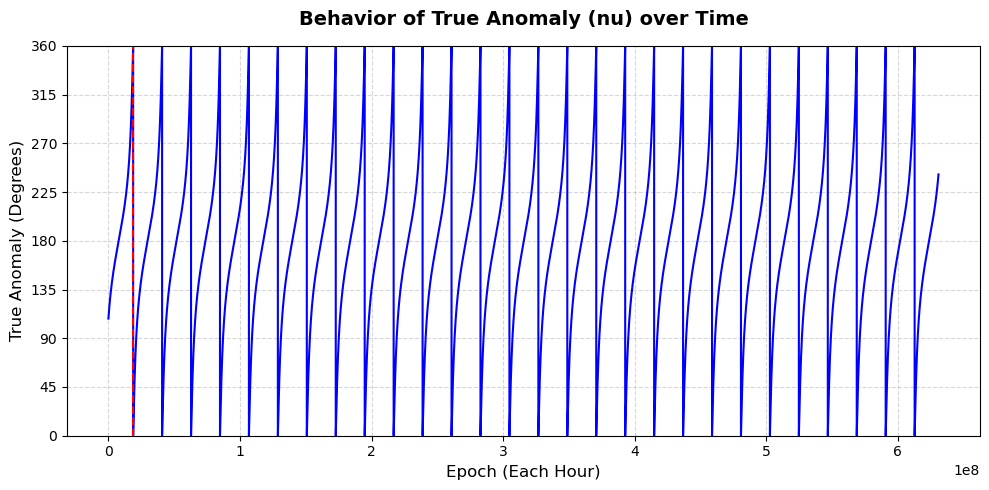

In [16]:
# To see how nu (true anomaly) really behaves

# 1. Extract and sort the data by epoch to ensure chronological order
epochs = sorted(kepler_history.keys())
# Index 5 is the true anomaly (nu)
nu_radians = [kepler_history[epoch][5] for epoch in epochs]

# 2. Convert radians to degrees and normalize between 0 and 360 degrees
nu_degrees = np.degrees(nu_radians)
nu_degrees_normalized = [nu % 360 for nu in nu_degrees]

# 3. Create the plot
plt.figure(figsize=(10, 5), dpi=100)
plt.plot(epochs, nu_degrees_normalized, color='blue', linewidth=1.5, label='True Anomaly (nu)')
plt.axvline(18838800.0, color='red', linestyle='--', linewidth=1.5)

# 4. Format and style the plot
plt.title('Behavior of True Anomaly (nu) over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epoch (Each Hour)', fontsize=12)
plt.ylabel('True Anomaly (Degrees)', fontsize=12)

# Set y-axis ticks every 45 degrees for better readability
plt.ylim(0, 360)
plt.yticks(np.arange(0, 361, 45))

# Add a clean grid layout
plt.grid(True, linestyle='--', alpha=0.5)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [17]:
epochs = []
omega_values_anglejump = []
true_anomaly_list = []
epoch_perihelion_list = []
index_list_peri = []

# To detect the perihelion in time
previous_nu = None

for i, (epoch, kep) in enumerate(kepler_history.items(), start=1):

    # Extract the true anomaly
    nu = kep[5]

    if previous_nu is not None:

        # Detect wraparound near perihelion
        # Cause there will be a jump from 2pi to 0
        if previous_nu > (3/2)*np.pi and nu < (1/2)*np.pi:
            
            epoch_perihelion_close = epoch
            epoch_perihelion_list.append(epoch_perihelion_close)
            index_list_peri.append(i)

            # epoch_days = epoch / (3600*24)
            # print(f"The perihelion is near the epoch of {epoch_perihelion_close}")

    previous_nu = nu

    # Extract the perihelion precession as well

    omega_test = kep[3]
    epochs.append(epoch)

    omega_values_anglejump.append(omega_test)

    

# Unwrap the angles :)
# Makes e.g. 359, 0, 1 degrees to 359, 360, 361 etc.
omega_values = np.unwrap(omega_values_anglejump)
omega_values_degrees = np.degrees(omega_values)

zoom_in_first_perihelion = omega_values_degrees[0:6113]

#print(f"Omega values before and after perihelion: {zoom_in_first_perihelion}")
print()
#print(f"Omega values before and after perihelion: {omega_values[5230:5250]}")
print(epoch_perihelion_list)
print(index_list_peri)


# The indicies below were inserted manually (I read off the printed list below)
# The perihelion precession during the first year
first_peri = perihelion_precess = np.degrees(omega_values[11354] -  omega_values[5234])
# The perihelion precession after 15 years
peri_precess_15_years = np.degrees(omega_values[-1] - omega_values[5234])

peri_precession_per_orbit_list = []

for i in index_list_peri:
    peri_deg = np.degrees(omega_values[i+1] -  omega_values[i])
    peri_precession_per_orbit_list.append(peri_deg)

print(first_peri)
print(peri_precess_15_years)
print(peri_precession_per_orbit_list)



[18774000.0, 40780800.0, 62787600.0, 84794400.0, 106801200.0, 128808000.0, 150814800.0, 172825200.0, 194832000.0, 216838800.0, 238845600.0, 260852400.0, 282859200.0, 304866000.0, 326872800.0, 348879600.0, 370886400.0, 392893200.0, 414900000.0, 436906800.0, 458913600.0, 480924000.0, 502930800.0, 524937600.0, 546944400.0, 568951200.0, 590958000.0, 612964800.0]
[5228, 11341, 17454, 23567, 29680, 35793, 41906, 48020, 54133, 60246, 66359, 72472, 78585, 84698, 90811, 96924, 103037, 109150, 115263, 121376, 127489, 133603, 139716, 145829, 151942, 158055, 164168, 170281]
1.733892108090784e-05
0.0004873240598255964
[-2.388821749050549e-08, -2.3888357434911472e-08, -2.3888497379317456e-08, -2.3888624601504713e-08, -2.388875182369197e-08, -2.3888891768097958e-08, -2.388900626806649e-08, -2.3887110657476337e-08, -2.38872887685385e-08, -2.3887466879600663e-08, -2.3887632268444097e-08, -2.3887797657287535e-08, -2.3887950323912244e-08, -2.3888102990536953e-08, -2.388824293494294e-08, -2.3888382879348

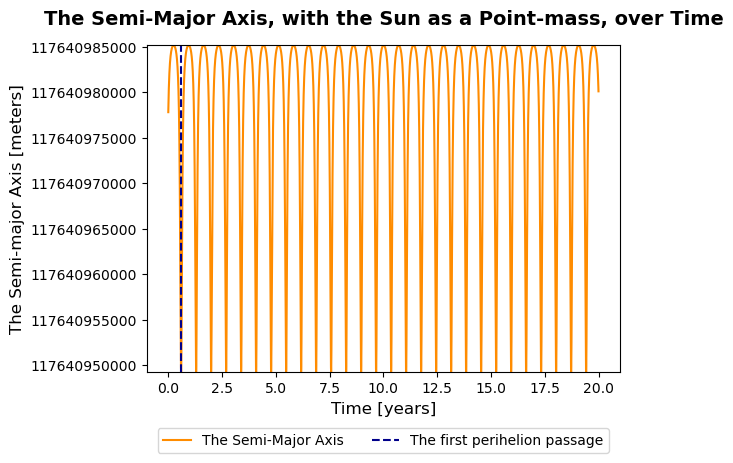

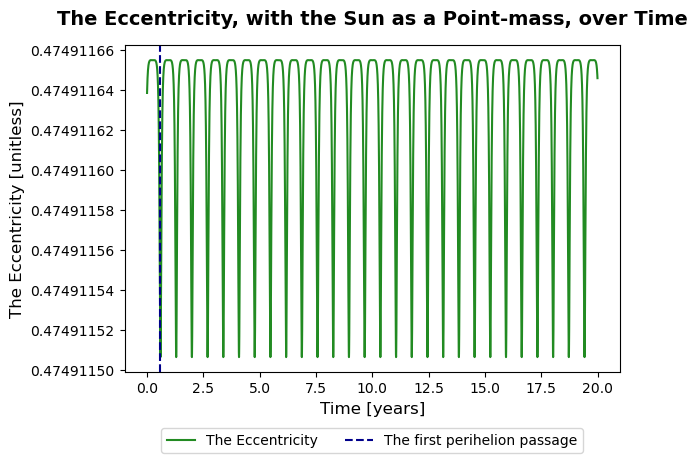

In [18]:
epochs_years = np.array(epochs) / (365.25 * 24 * 3600)
first_perihelion_in_years = np.array(epoch_perihelion_list[0]) / (365.25 * 24 * 3600)


first_perihelion_in_years = np.array(18774000.0 / (365.25 * 24 * 3600))

one_AU = 149597870691   # meters
a_kep = np.array(a_kep_list) #/ one_AU

#plt.subplot(2, 2, 1)
plt.plot(epochs_years, a_kep, color='darkorange', label='The Semi-Major Axis')
plt.axvline(first_perihelion_in_years, color='darkblue', linestyle='--', linewidth=1.5, label='The first perihelion passage')

plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.title('The Semi-Major Axis, with the Sun as a Point-mass, over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time [years]', fontsize=12)
plt.ylabel('The Semi-major Axis [meters]', fontsize=12)

plt.ylim(np.min(a_kep) - 0.02, np.max(a_kep) + 0.02)

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)

plt.tight_layout()
plt.show()

#plt.subplot(2, 2, 2)
plt.plot(epochs_years, e_kep_list, color='forestgreen', label='The Eccentricity')
plt.axvline(first_perihelion_in_years, color='darkblue', linestyle='--', linewidth=1.5, label='The first perihelion passage')

plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.title('The Eccentricity, with the Sun as a Point-mass, over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time [years]', fontsize=12)
plt.ylabel('The Eccentricity [unitless]', fontsize=12)

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)

plt.tight_layout()
plt.show()

In [19]:
print(np.polyfit(epochs,a_kep_list,1)[0])
print(np.polyfit(epochs,e_kep_list,1)[0])

-8.748994400316738e-09
-1.0361802575405523e-19


3057.0
11003400.0
175321


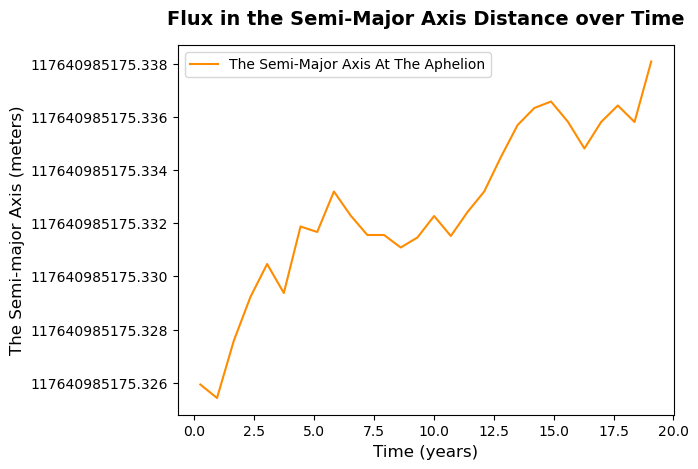

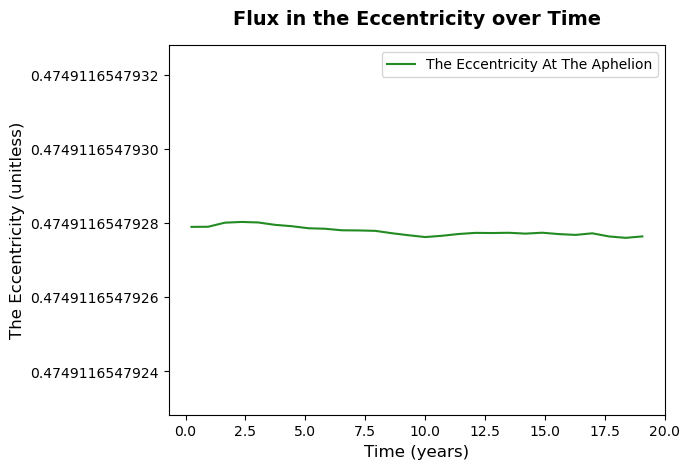

In [20]:
# Extracting the points of the orbit at the aphelion

# This is a brute force method
# Add half of the total indicies amoutn for one orbit
half_i = (index_list_peri[1] - index_list_peri[0] + 1) / 2
print(half_i)

half_time = (epoch_perihelion_list[1] - epoch_perihelion_list[0]) / 2
print(half_time)

print(len(a_kep_list))

index_list_aphelion = []
a_aphelion_list = []
e_aphelion_list = []
time_aphelion_list = []

for i, peri_i in enumerate(index_list_peri):
    # # Otherwise I will reach a point where the aphelion is out of range
    # if i =! -1:
    
        # This is a brute force method
        # Add half of the total indicies amoutn for one orbit
        i_aphelion = peri_i - half_i
        index_list_aphelion.append(i_aphelion)

        a_aphelion = a_kep_list[int(i_aphelion)]
        e_aphelion = e_kep_list[int(i_aphelion)]
        time_aphelion = epochs_years[int(i_aphelion)]

        a_aphelion_list.append(a_aphelion)
        e_aphelion_list.append(e_aphelion)
        time_aphelion_list.append(time_aphelion)

#plt.subplot(2, 2, 1)
plt.plot(time_aphelion_list, a_aphelion_list, color='darkorange', label='The Semi-Major Axis At The Aphelion')
# plt.axvline(first_perihelion_in_years, color='darkblue', linestyle='--', linewidth=1.5, label='The first perihelion passage')

plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.title('Flux in the Semi-Major Axis Distance over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time (years)', fontsize=12)
plt.ylabel('The Semi-major Axis (meters)', fontsize=12)

plt.legend()
plt.show()

#plt.subplot(2, 2, 2)
plt.plot(time_aphelion_list, e_aphelion_list, color='forestgreen', label='The Eccentricity At The Aphelion')
# plt.axvline(first_perihelion_in_years, color='darkblue', linestyle='--', linewidth=1.5, label='The first perihelion passage')

plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.title('Flux in the Eccentricity over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time (years)', fontsize=12)
plt.ylabel('The Eccentricity (unitless)', fontsize=12)

plt.legend()
plt.show()

In [21]:
epochs = []
omega_values_anglejump = []
true_anomaly_list = []
epoch_perihelion_list = []
index_list_peri = []

# To detect the perihelion in time
previous_nu = None

for i, (epoch, kep) in enumerate(kepler_history.items(), start=1):

    # Extract the true anomaly
    nu = kep[5]

    if previous_nu is not None:

        # Detect wraparound near perihelion
        # Cause there will be a jump from 2pi to 0
        if previous_nu > (3/2)*np.pi and nu < (1/2)*np.pi:
            
            epoch_perihelion_close = epoch
            epoch_perihelion_list.append(epoch_perihelion_close)
            index_list_peri.append(i)

            # epoch_days = epoch / (3600*24)
            # print(f"The perihelion is near the epoch of {epoch_perihelion_close}")

    previous_nu = nu

    # Extract the perihelion precession as well

    omega_test = kep[3]
    epochs.append(epoch)

    omega_values_anglejump.append(omega_test)

    

# Unwrap the angles :)
# Makes e.g. 359, 0, 1 degrees to 359, 360, 361 etc.
omega_values = np.unwrap(omega_values_anglejump)
omega_values_degrees = np.degrees(omega_values)

zoom_in_first_perihelion = omega_values_degrees[0:6113]

#print(f"Omega values before and after perihelion: {zoom_in_first_perihelion}")
print()
#print(f"Omega values before and after perihelion: {omega_values[5230:5250]}")
print(epoch_perihelion_list)
print(index_list_peri)


# The indicies below were inserted manually (I read off the printed list below)
# The perihelion precession during the first year
first_peri = perihelion_precess = np.degrees(omega_values[11354] -  omega_values[5234])
# The perihelion precession after 15 years
peri_precess_15_years = np.degrees(omega_values[-1] - omega_values[5234])

peri_precession_per_orbit_list = []

for i in index_list_peri:
    peri_deg = np.degrees(omega_values[i+1] -  omega_values[i])
    peri_precession_per_orbit_list.append(peri_deg)

print(first_peri)
print(peri_precess_15_years)
print(peri_precession_per_orbit_list)



[18774000.0, 40780800.0, 62787600.0, 84794400.0, 106801200.0, 128808000.0, 150814800.0, 172825200.0, 194832000.0, 216838800.0, 238845600.0, 260852400.0, 282859200.0, 304866000.0, 326872800.0, 348879600.0, 370886400.0, 392893200.0, 414900000.0, 436906800.0, 458913600.0, 480924000.0, 502930800.0, 524937600.0, 546944400.0, 568951200.0, 590958000.0, 612964800.0]
[5228, 11341, 17454, 23567, 29680, 35793, 41906, 48020, 54133, 60246, 66359, 72472, 78585, 84698, 90811, 96924, 103037, 109150, 115263, 121376, 127489, 133603, 139716, 145829, 151942, 158055, 164168, 170281]
1.733892108090784e-05
0.0004873240598255964
[-2.388821749050549e-08, -2.3888357434911472e-08, -2.3888497379317456e-08, -2.3888624601504713e-08, -2.388875182369197e-08, -2.3888891768097958e-08, -2.388900626806649e-08, -2.3887110657476337e-08, -2.38872887685385e-08, -2.3887466879600663e-08, -2.3887632268444097e-08, -2.3887797657287535e-08, -2.3887950323912244e-08, -2.3888102990536953e-08, -2.388824293494294e-08, -2.3888382879348

7.952839935330688e-13


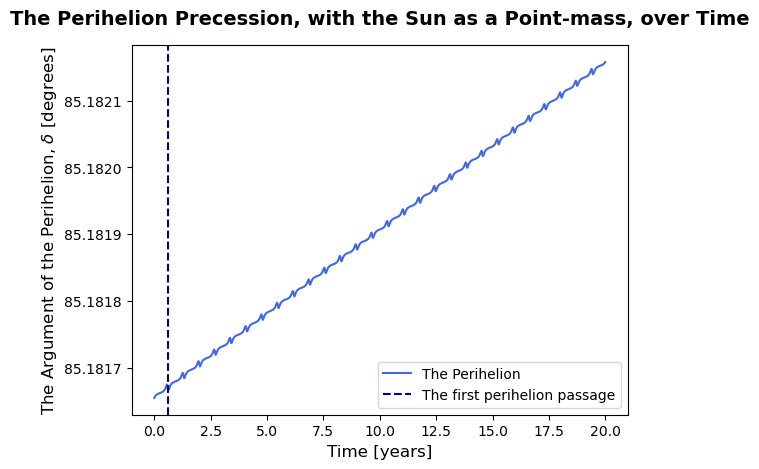

In [22]:
plt.plot(epochs_years, np.degrees(omega_values), label='The Perihelion', color='royalblue')
# plt.axvline(18838800.0, color='red', linestyle='--', linewidth=1.5)
plt.axvline(first_perihelion_in_years, color='darkblue', linestyle='--', linewidth=1.5, label='The first perihelion passage')

# # Check a linear relation going through the oscillations
lin_slope = np.polyfit(epochs,np.degrees(omega_values),1)[0]
print(lin_slope)
# y_test = 85.15 + lin_slope * np.array(epochs)
# plt.plot(epochs, y_test)

plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.title('The Perihelion Precession, with the Sun as a Point-mass, over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time [years]', fontsize=12)
plt.ylabel('The Argument of the Perihelion, $\delta$ [degrees]', fontsize=12)

# plt.ylim(85, 85.5)
plt.legend()
plt.show()

In [23]:
# Finding the slope

# Arcseconds
omega_arcseconds = np.degrees(omega_values) * 3600

# The epochs are currently in seconds, when they should be per century
epochs_centuery = np.array(epochs) / (100 * 365 * 24 * 3600)

print(np.polyfit(epochs,np.degrees(omega_values),1)[0])
print(f"The perihelion precession: {np.polyfit(epochs_centuery,omega_arcseconds,1)[0]} arcesconds/ century")

7.952839935330688e-13
The perihelion precession: 9.028827369095008 arcesconds/ century


85.1816557837214 85.18165578371935
1.1792923566944454e-21


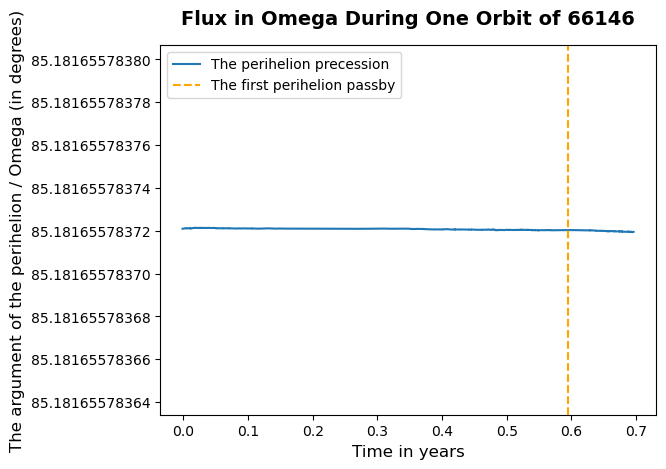

In [ ]:
# To zoom in on the first perihelion
epoch_zoom_in = epochs[0:6113]       # I'm not sure that the indicies are lining up
epoch_zoom_in_years = np.array(epoch_zoom_in) / (365.25 * 24 * 3600)

first_perihelion_in_years = 18774000.0 / (365.25 * 24 * 3600)

zoom_in_first_perihelion = np.array(zoom_in_first_perihelion)

# Finding the values on the y-axis
w_max = np.max(zoom_in_first_perihelion)
w_min = np.min(zoom_in_first_perihelion)

print(w_max, w_min)

plt.plot(epoch_zoom_in_years, zoom_in_first_perihelion, label='The perihelion precession')
# plt.axvline(18838800.0, color='red', linestyle='--', linewidth=1.5)
plt.axvline(first_perihelion_in_years, color='orange', linestyle='--', linewidth=1.5, label='The first perihelion passby')

# # Check a linear relation going through the oscillations
lin_slope = np.polyfit(epochs,np.degrees(omega_values),1)[0]
print(lin_slope)
# y_test = 85.15 + lin_slope * np.array(epochs)
# plt.plot(epochs, y_test)

plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.title('Flux in Omega During One Orbit of 66146', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time in years', fontsize=12)
plt.ylabel('The argument of the perihelion / Omega (in degrees)', fontsize=12)

#plt.ylim(85.18165477101, 85.18165477103)

plt.legend()
plt.show()